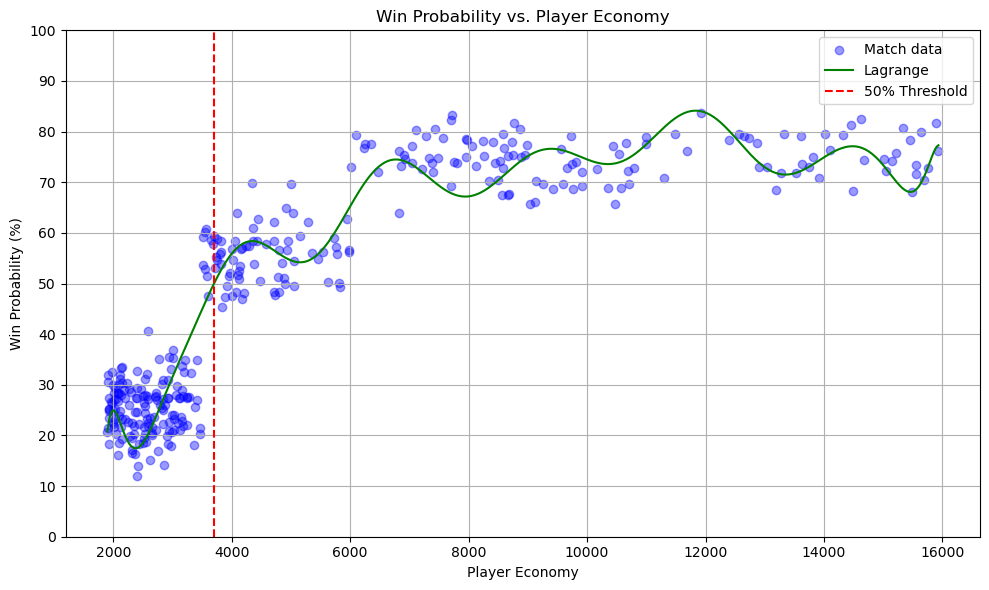

In [13]:
import csv
import matplotlib.pyplot as plt

def read_csv(filename):
    x_vals = []
    y_vals = []
    with open(filename, newline = "") as file:
        reader = csv.DictReader(file)
        for row in reader:
            x_vals.append(float(row["player_economy"]))
            y_vals.append(float(row["econ_effectiveness"]))
    return x_vals, y_vals

def sample_points(x, y, n = None):
    sample_x = [1900, 2000, 2500, 2800, 3600, 4400, 5500, 7000, 8500, 9500, 11000, 12000, 13000, 13500, 13750, 14900, 15500, 15750, 16000]
    sample_y = []

    for econ in sample_x:
        closest = min(zip(x, y), key = lambda pair: abs(pair[0] - econ))
        sample_y.append(closest[1])

    return sample_x, sample_y


# Lagrange 
def lagrange(x_vals, y_vals):
    def L(k, x):
        result = 1
        for i in range(len(x_vals)):
            if i != k:
                result *= (x - x_vals[i]) / (x_vals[k] - x_vals[i])
        return result

    def P(x):
        return sum(y_vals[k] * L(k, x) for k in range(len(x_vals)))
    
    return P

def win_percentage(econ_value, x, y):
    x_sample, y_sample = sample_points(x, y, n = 20)
    poly = lagrange(x_sample, y_sample)
    prediction = max(0, min(1, poly(econ_value)))
    return round(prediction * 100, 2)

# Newton/Secant
def newtonSecant(f, x0, x1, tol = 1e-5, max_iter = 50):
    for _ in range(max_iter):
        f_x0 = f(x0)
        f_x1 = f(x1)
        if f_x1 - f_x0 == 0:
            return None
        x2 = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)
        if abs(x2 - x1) < tol:
            return x2
        x0, x1 = x1, x2
    return None

# Threshold
def threshold(x, y):
    x_sample, y_sample = sample_points(x, y, n = 20)
    poly = lagrange(x_sample, y_sample)
    def f(e): return poly(e) - 0.5

    for i in range(len(x_sample) - 1):
        if (y_sample[i] - 0.5) * (y_sample[i + 1] - 0.5) < 0:
            result = newtonSecant(f, x_sample[i], x_sample[i + 1])
            if result:
                return round(result)
    return None

# Plot
def plot(x, y):
    x_sample, y_sample = sample_points(x, y, n = 20)
    poly = lagrange(x_sample, y_sample)

    x_min, x_max = min(x), max(x)
    x_vals = [x_min + i * (x_max - x_min) / 500 for i in range(501)]
    y_vals = [max(0, min(1, poly(val))) for val in x_vals]

    threshold2 = threshold(x, y)

    plt.figure(figsize = (10, 6))
    plt.scatter(x, [v * 100 for v in y], color = "blue", alpha = 0.4, label = "Match data")
    plt.plot(x_vals, [v * 100 for v in y_vals], color = "Green", label = "Lagrange")
    if threshold:
        plt.axvline(threshold2, color = "red", linestyle = "--", label = f"50% Threshold")
    plt.xlabel("Player Economy")
    plt.ylabel("Win Probability (%)")
    plt.title("Win Probability vs. Player Economy")
    plt.grid(True)
    plt.yticks(range(0, 101, 10))
    plt.legend()
    plt.tight_layout()
    plt.show()


    

x, y = read_csv("match_data.csv")
plot(x, y)

In [14]:
player_eco = 16000


In [15]:
print(f"Win percentage at ${player_eco}: %{win_percentage(player_eco, x, y)}")

threshold2 = threshold(x, y)
if threshold2:
    print(f"50% win threshold (secant/newton): ${threshold2}")
else:
    print("Threshold not found")

Win percentage at $16000: %76.2
50% win threshold (secant/newton): $3700
